In [9]:
import math
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from tqdm import tqdm
from collections import defaultdict
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objs as go
from matplotlib.animation import FuncAnimation
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import RobustScaler
from gtda.time_series import TakensEmbedding
# import helper_function as hf

In [10]:
beh_anno=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\manual_annotation.csv",header=None)
df_head_curvature=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\head_curvature.csv",header=None)
df_speed=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\centroid_speed.csv",header=None)
df_angular_speed=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\angular_speed.csv",header=None)
df_head_freq=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\head_oscillation_frequency.csv",header=None)
df_curvature=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\total_curvature.csv",header=None)
df_rev_run=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\time_from_rev.csv",header=None)
df_roam_dwell=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\roaming_dwelling_vector.csv",header=None)

In [3]:
df_curvature

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,20.246127,25.732083,22.885236,18.468474,25.744319,23.361030,28.868792,33.809911,25.306026,30.733125,...,29.163575,41.978144,26.696571,24.019547,32.216167,23.106340,26.384565,34.822245,28.378499,23.700052
1,21.717368,25.403490,23.706743,18.682847,28.219134,22.714011,28.777879,35.300807,23.976819,35.421535,...,29.738334,43.297059,27.014207,24.704911,31.641221,27.163186,24.935679,31.698313,30.442631,21.576093
2,20.696712,25.575134,25.733406,19.806698,24.738527,22.020560,29.568129,38.385885,25.441716,31.938336,...,31.030634,41.243350,27.023945,26.935939,31.312941,26.589127,27.465546,34.578460,31.084471,21.521625
3,16.660999,25.474328,28.915578,18.420051,24.943614,19.865485,28.755010,34.894591,23.715985,29.337238,...,30.255391,36.086859,25.780003,26.628293,35.218479,27.499053,24.888123,34.335865,35.118715,22.032401
4,16.259001,26.980046,34.510465,19.186647,23.906097,20.004895,30.271035,46.204525,23.815691,29.120771,...,28.944886,42.186311,26.110558,29.634096,33.998530,23.880530,30.088201,32.044369,35.562513,23.712695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18896,24.585520,22.322464,25.151399,33.403306,28.509126,19.585819,28.082535,24.558380,NaN,27.436349,...,26.368935,34.944464,31.521298,26.811805,33.233569,20.941504,46.565925,54.282255,22.860538,25.990944
18897,25.968368,22.427251,23.514268,27.168086,34.434871,21.928379,24.352185,25.420289,NaN,28.303238,...,28.877303,34.316219,35.207173,29.093493,30.011589,19.171201,47.050987,81.820237,23.124803,26.467432
18898,23.866753,22.213060,23.701714,27.361168,33.570753,24.953153,24.388726,26.352829,NaN,27.932201,...,24.550529,33.363046,31.689955,23.146278,32.656554,21.237670,60.168582,81.820237,22.979089,24.671273
18899,25.975360,24.785458,22.695080,27.392125,31.292241,23.883894,24.128828,33.629314,NaN,NaN,...,26.134486,41.510854,31.024928,24.916823,31.836500,23.199242,57.088718,81.820237,24.300815,26.028520


In [11]:
#remove unreasonable numbers (outliers)
df_curvature[df_curvature>=1000]=np.nan

In [12]:
def stack_rows_to_columns_with_groups(df_list, df_names):
    stacked_columns = pd.DataFrame()
    groups = []  # List to store worm identity (row number)

    # Ensure the groups are repeated 18900 times for each worm (1 to 25)
    for row_num in range(25):  # Assuming there are 25 worms
        groups.extend([row_num + 1] * 18900)  # Repeat row number for 18900 columns

    for i, df in enumerate(df_list):
        # Stack each row of the dataframe to make one column, keeping NaN values
        stacked = df.stack(dropna=False).reset_index(drop=True)

        # Append the stacked column to the final DataFrame with the corresponding name
        stacked_columns[df_names[i]] = stacked

    # Verify that the lengths match
    total_length = len(stacked_columns)  # Length of the stacked DataFrame
    if len(groups) == total_length:
        # Add the 'groups' column indicating worm identity at the end
        stacked_columns['groups'] = groups
    else:
        raise ValueError(f"Length of groups ({len(groups)}) does not match length of stacked columns ({total_length})")

    # Return the final DataFrame with each stacked DataFrame as a column and the groups column
    return stacked_columns

# Example usage with df_list and df_names
df_list = [df_speed, df_angular_speed, df_head_freq.T, df_curvature.T, df_head_curvature.T,df_rev_run,df_roam_dwell, beh_anno.T]
df_names = ['speed', 'angular_speed', 'head_freq', 'curvature', 'head_curvature', 'rev_run', 'roam_dwell', 'behaviour_anno']

result = stack_rows_to_columns_with_groups(df_list, df_names)
print(result)

          speed  angular_speed  head_freq  curvature  head_curvature  rev_run  \
0       0.14714            NaN        0.0  20.246127       -0.047936      NaN   
1       0.14714   2.174744e+00        0.0  21.717368       -0.044926      NaN   
2       0.13000   1.692053e+00        1.0  20.696712        0.042119      NaN   
3       0.13161   2.039344e+00        1.0  16.660999        0.005659      NaN   
4       0.12394   5.192646e-11        1.0  16.259001       -0.001187      NaN   
...         ...            ...        ...        ...             ...      ...   
472495  0.20915   1.255975e+00        2.0  21.101184        0.069842   3422.0   
472496  0.16003   6.771153e-01        2.0  23.087742        0.051328      6.0   
472497  0.20087   1.068791e+00        2.0  21.625291        0.041933      6.0   
472498  0.16836   5.874298e-01        2.0  21.824766        0.056095    264.0   
472499      NaN            NaN        3.0  22.632474        0.038085    612.0   

        roam_dwell  behavio

In [13]:
# Drop rows where 'behaviour_anno' column contains NaN
result = result.dropna(subset=['behaviour_anno'],axis=0)

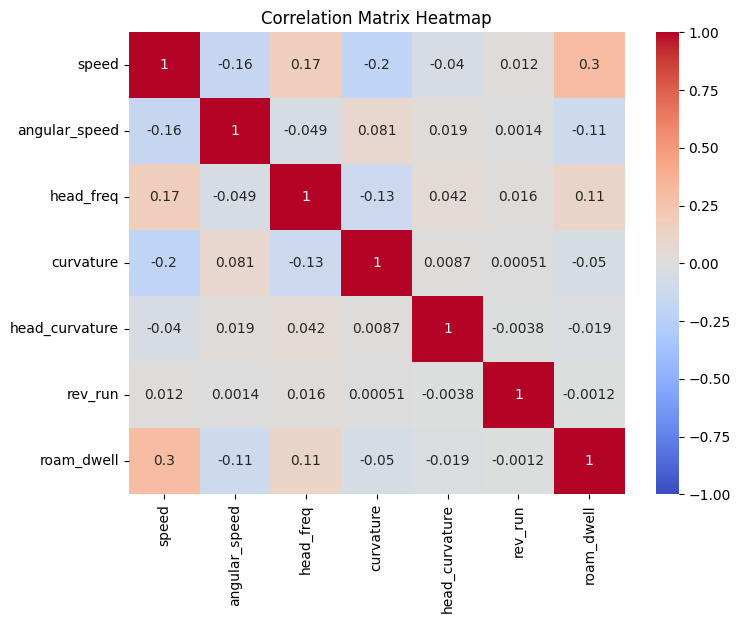

In [14]:
import seaborn as sns
correlation_matrix = result.drop({'groups','behaviour_anno'},axis=1).corr()

plt.figure(figsize=(8, 6))

# Create a heatmap using seaborn
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0)

# Set title
plt.title('Correlation Matrix Heatmap')

# Show the plot
plt.show()

In [15]:
fps=10
response=pd.read_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\response_annotation.csv",header=None)
trigger_points = np.arange(457, 1890, 90)  # Starting from 450 seconds, increment by 90 seconds
# window_size = 15  # ±7 seconds window
# frame_window_size = int(window_size * fps)  # Convert to frames
min_win= int(60 * fps)
max_win= int(30 * fps)
def trig_average(df):
    all_speeds = []
    annotation=[]
    triggered_speed = [] 
    group=[]
    triggered_speeds_df=pd.DataFrame()
    for i in range(df.shape[0]):
        speed = df.iloc[i,:]
        anno=response.iloc[i,:]
        annotation.append(anno.values)
        # speed[speed > 0.3] = np.NaN
        all_speeds.append(speed)
        
        for trigger_point in trigger_points:
        # Find the indices within the window around the trigger point
            frame_trigger_point = int(trigger_point * fps)  # Convert to frames

        # Calculate the frame indices for the window
            window_start = frame_trigger_point - min_win
            window_end = frame_trigger_point + max_win

        # Extract the speeds within the window
            window_speeds = speed[window_start:window_end]
        # Append the window speeds to the container
            triggered_speed.append(window_speeds.values)
            
            
    triggered_speeds_df = pd.DataFrame(triggered_speed)
    
    triggered_speeds_df['annotation'] = response.stack(dropna=False).values.reshape(-1, 1)
    # Add a 'group' column: Each group label (1 to 25) repeated 16 times
    num_groups = 25
    repeats_per_group = 16
    total_repeats = num_groups * repeats_per_group
    triggered_speeds_df['group'] = np.repeat(np.arange(1, num_groups + 1), repeats_per_group)[:len(triggered_speeds_df)]
    return triggered_speeds_df

In [16]:
#taking trig-average
df_trig_speed=trig_average(df_speed)
df_trig_ang_speed=trig_average(df_angular_speed)
df_trig_head_freq=trig_average(df_head_freq.T)
df_trig_curvature=trig_average(df_curvature.T)
df_trig_rev_run=trig_average(df_rev_run.T/fps)
df_trig_roam_dwell=trig_average(df_roam_dwell)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,20.246127,25.732083,22.885236,18.468474,25.744319,23.361030,28.868792,33.809911,25.306026,30.733125,...,29.163575,41.978144,26.696571,24.019547,32.216167,23.106340,26.384565,34.822245,28.378499,23.700052
1,21.717368,25.403490,23.706743,18.682847,28.219134,22.714011,28.777879,35.300807,23.976819,35.421535,...,29.738334,43.297059,27.014207,24.704911,31.641221,27.163186,24.935679,31.698313,30.442631,21.576093
2,20.696712,25.575134,25.733406,19.806698,24.738527,22.020560,29.568129,38.385885,25.441716,31.938336,...,31.030634,41.243350,27.023945,26.935939,31.312941,26.589127,27.465546,34.578460,31.084471,21.521625
3,16.660999,25.474328,28.915578,18.420051,24.943614,19.865485,28.755010,34.894591,23.715985,29.337238,...,30.255391,36.086859,25.780003,26.628293,35.218479,27.499053,24.888123,34.335865,35.118715,22.032401
4,16.259001,26.980046,34.510465,19.186647,23.906097,20.004895,30.271035,46.204525,23.815691,29.120771,...,28.944886,42.186311,26.110558,29.634096,33.998530,23.880530,30.088201,32.044369,35.562513,23.712695
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18896,24.585520,22.322464,25.151399,33.403306,28.509126,19.585819,28.082535,24.558380,NaN,27.436349,...,26.368935,34.944464,31.521298,26.811805,33.233569,20.941504,46.565925,54.282255,22.860538,25.990944
18897,25.968368,22.427251,23.514268,27.168086,34.434871,21.928379,24.352185,25.420289,NaN,28.303238,...,28.877303,34.316219,35.207173,29.093493,30.011589,19.171201,47.050987,81.820237,23.124803,26.467432
18898,23.866753,22.213060,23.701714,27.361168,33.570753,24.953153,24.388726,26.352829,NaN,27.932201,...,24.550529,33.363046,31.689955,23.146278,32.656554,21.237670,60.168582,81.820237,22.979089,24.671273
18899,25.975360,24.785458,22.695080,27.392125,31.292241,23.883894,24.128828,33.629314,NaN,NaN,...,26.134486,41.510854,31.024928,24.916823,31.836500,23.199242,57.088718,81.820237,24.300815,26.028520


In [67]:
#mean of 5 sec
window=5
start_frame = min_win - (5 * fps) + 1
end_frame = min_win
df=pd.DataFrame()
df['speed']=df_trig_speed.loc[:,start_frame:end_frame].mean(axis=1, skipna=True)
df['Angular_speed']=df_trig_ang_speed.loc[:,start_frame:end_frame].mean(axis=1, skipna=True)
df['rev_run']=df_trig_rev_run.loc[:,start_frame:end_frame].mean(axis=1, skipna=True)
df['curvature']=df_trig_curvature.loc[:,start_frame:end_frame].mean(axis=1, skipna=True)
df['head_frequency']=df_trig_head_freq.loc[:,start_frame:end_frame].mean(axis=1, skipna=True)
df['roam_dwell']=df_trig_roam_dwell.loc[:,start_frame:end_frame].mean(axis=1, skipna=True)
df['group']=df_trig_speed.iloc[:,-1]
df['target']=df_trig_speed.iloc[:,-2]
df

,speed,Angular_speed,rev_run,curvature,head_frequency,roam_dwell,group,target
0,0.055587,1.896415,10.25,23.661260,1.74,1.0,1,1.0
1,0.188738,1.042529,26.65,23.706435,2.16,1.0,1,1.0
2,0.140867,1.968296,59.85,23.596653,2.22,1.0,1,0.0
3,0.089850,0.654899,11.75,25.481219,2.00,1.0,1,1.0
4,0.136494,7.667280,8.85,24.112978,2.00,1.0,1,1.0
...,...,...,...,...,...,...,...,...
395,0.172223,1.265728,62.35,24.827768,2.10,1.0,25,1.0
396,0.182694,3.928084,59.31,27.508887,1.52,1.0,25,NaN
397,0.127670,0.761492,25.35,26.036395,2.10,1.0,25,0.0
398,0.176805,0.932002,26.65,26.073984,1.88,1.0,25,NaN


In [64]:
column_vec_speed=df_trig_speed.iloc[:,550:600].stack(dropna=False).values.reshape(-1, 1)
column_vec_ang_speed=df_trig_ang_speed.iloc[:,550:600].stack(dropna=False).values.reshape(-1, 1)
column_vec_head_freq=df_trig_head_freq.iloc[:,550:600].stack(dropna=False).values.reshape(-1, 1)
column_vec_curvature=df_trig_curvature.iloc[:,550:600].stack(dropna=False).values.reshape(-1, 1)
column_vec_rev_run=df_trig_rev_run.iloc[:,550:600].stack(dropna=False).values.reshape(-1, 1)
column_vec_roam_dwell=df_trig_roam_dwell.iloc[:,550:600].stack(dropna=False).values.reshape(-1, 1)
tar=[]
group=[]
for index, row in df_trig_speed.iterrows():
    tar.append(np.full(50,df_trig_speed.iloc[index]['annotation']))
    group.append(np.full(50,df_trig_speed.iloc[index]['group']))
Y=pd.DataFrame(tar)
gr=pd.DataFrame(group)
target=Y.stack(dropna=False).values.reshape(-1, 1) 
groups=gr.stack(dropna=False).values.reshape(-1, 1)

df_for_pls_pre=pd.DataFrame(data=np.c_[column_vec_speed,column_vec_ang_speed,column_vec_head_freq,column_vec_curvature,column_vec_rev_run,column_vec_roam_dwell,target,groups])
df_for_pls_pre.columns = ['speed','Angular_speed','head_frequency','curvature','rev_run','roam_dwell','target','group']
# df_for_pls_pre=pd.DataFrame(data=np.c_[column_vec_speed,column_vec_rev_run,target,groups])
# df_for_pls_pre.columns = ['speed','rev_run','target','group']
dj=df_for_pls_pre.dropna(subset=['target'], inplace=False)

from sklearn.impute import SimpleImputer
imp=SimpleImputer(strategy='mean')
dk=imp.fit_transform(dj.drop({'target','group'}, axis=1))
df_prestim_imputed=pd.DataFrame(data=np.c_[dk,dj['target'],dj['group']])
df_prestim_imputed.columns=dj.columns
df_prestim_imputed

,speed,Angular_speed,head_frequency,curvature,rev_run,roam_dwell,target,group
0,0.101390,1.056719,2.0,28.409237,7.7,1.0,1.0,1.0
1,0.060083,0.411576,2.0,28.941817,7.8,1.0,1.0,1.0
2,0.050606,1.236145,2.0,27.305362,7.9,1.0,1.0,1.0
3,0.054424,0.811091,1.0,27.598544,8.0,1.0,1.0,1.0
4,0.055902,1.543404,1.0,40.060565,8.1,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...
16095,0.220100,1.182803,3.0,23.648087,21.4,1.0,1.0,25.0
16096,0.217330,0.768065,2.0,23.030874,21.5,1.0,1.0,25.0
16097,0.155710,0.413079,2.0,23.417853,21.6,1.0,1.0,25.0
16098,0.155710,0.324740,2.0,22.212411,21.7,1.0,1.0,25.0


In [68]:
df_for_lda=df[~df['target'].isna()]
df_nonan=df_for_lda[~df['speed'].isna()]

In [69]:
df_nonan

,speed,Angular_speed,rev_run,curvature,head_frequency,roam_dwell,group,target
0,0.055587,1.896415,10.25,23.661260,1.74,1.0,1,1.0
1,0.188738,1.042529,26.65,23.706435,2.16,1.0,1,1.0
2,0.140867,1.968296,59.85,23.596653,2.22,1.0,1,0.0
3,0.089850,0.654899,11.75,25.481219,2.00,1.0,1,1.0
4,0.136494,7.667280,8.85,24.112978,2.00,1.0,1,1.0
...,...,...,...,...,...,...,...,...
393,0.162188,0.903937,50.25,26.841334,2.00,1.0,25,0.0
394,0.122387,1.131978,140.25,24.531885,1.92,1.0,25,1.0
395,0.172223,1.265728,62.35,24.827768,2.10,1.0,25,1.0
397,0.127670,0.761492,25.35,26.036395,2.10,1.0,25,0.0


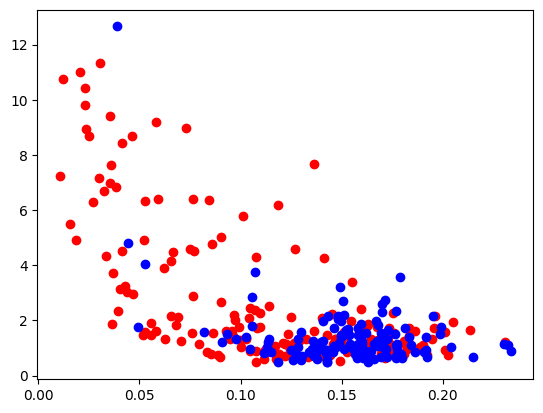

In [33]:
hit_ind = (df_for_lda['target'] == 1).values

plt.scatter(df_for_lda.loc[hit_ind, 'speed'], df_for_lda.loc[hit_ind, 'Angular_speed'], c='r')
plt.scatter(df_for_lda.loc[~hit_ind,  'speed'], df_for_lda.loc[~hit_ind,  'Angular_speed'], c='b')

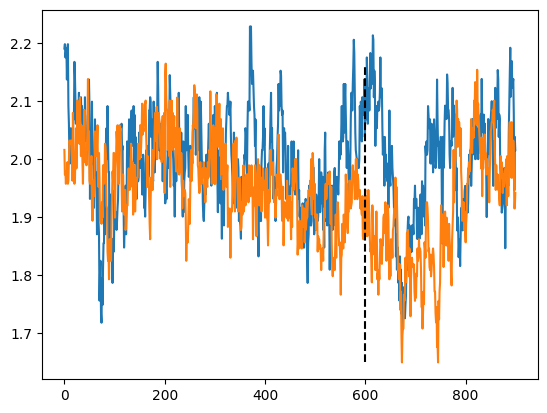

In [30]:
filtered_df_hit = df_trig_head_freq[df_trig_ang_speed['annotation'] == 1].iloc[:, :-2]
filtered_df_miss= df_trig_head_freq[df_trig_ang_speed['annotation'] == 0].iloc[:, :-2]
# Calculate the mean of each column and drop NaN values
mean_values_hit = filtered_df_hit.mean().dropna()
mean_values_miss = filtered_df_miss.mean().dropna()
plt.plot(mean_values_miss)
plt.plot(mean_values_hit)
plt.vlines(600, ymin=mean_values_hit.min(), ymax=mean_values_hit.max(), linestyles="--", color="k")

In [71]:
from numpy import mean
from numpy import std
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.model_selection import permutation_test_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import warnings
np.random.seed(0)
warnings.filterwarnings("ignore")
def single_lda(data):
    dg = pd.DataFrame(index=data.columns.drop(['target','group']),columns=['mean_accuracy','std','mean_score','perm_accuaracy','p-value'])
    for neuron in data.columns.drop(['target','group']):
        ind_nan=data[neuron].isna()
        ind=ind_nan[ind_nan==False].index
        X=data[[neuron]].dropna()
        y =data.loc[ind,'target']
        groups=data.loc[ind,'group']
            
        model= LinearDiscriminantAnalysis()
        #model= LogisticRegression()
        model.fit(X,y)
        # cv = RepeatedStratifiedKFold(n_splits=10, random_state=None)
        cv= StratifiedGroupKFold(n_splits=10,shuffle=True,random_state=0)
        #cv=GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        #cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        #cv=StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        # logo = LeaveOneGroupOut()
        # n_splits=logo.get_n_splits(X, y, groups)
        # cv=logo
        
        scores, perm_scores, pvalue = permutation_test_score(model, X, y, scoring="f1_weighted", cv=cv, groups=groups,n_permutations=100, random_state=0)
        cv_scores = cross_val_score(model, X, y, scoring="f1_weighted", cv=cv,groups=groups,n_jobs=1)
        print('Mean Accuracy: %.3f (%.3f)' % (mean(scores), std(cv_scores)))
        #print(scores)
        m=(mean(scores))
        s=(std(cv_scores))
        perm_mean_score=(mean(perm_scores))
        

        fig, ax = plt.subplots()

        hist_data, bins, _ = ax.hist(perm_scores, bins=20, density=True, color="tab:purple")
        # Calculate the x-coordinates for the shaded region
        # ax.errorbar(m, hist_data.max(), xerr=s, color="gray", lw=2, capsize=5)

        ax.axvline(m, ls="--", color="k")
        ax.axvline(perm_mean_score, ls="--", color="k")
        score_label = f"Score on original\ndata: {m:.2f}\n(p-value: {pvalue:.3f})"
        file_name = f"permutation_test_{neuron}.svg"
        ax.text(0.7, 10, score_label, fontsize=12)
        ax.set_xlabel("Accuracy score")
        _ = ax.set_ylabel("Probability density")
        plt.show()
        plt.savefig(file_name, format='svg')
        
        dg.loc[neuron, 'mean_accuracy'] = m
        dg.loc[neuron, 'mean_score'] = mean(cv_scores)
        dg.loc[neuron, 'std']=s
        dg.loc[neuron, 'perm_std']=std(perm_scores)
        dg.loc[neuron, 'perm_accuaracy'] = perm_mean_score
        dg.loc[neuron,'p-value']= pvalue
        
    return dg


In [28]:
# from chatGpt for debugging

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score, permutation_test_score

def single_neuron_lda(data):
    # Initialize a DataFrame to store results
    results_df = pd.DataFrame(index=data.columns.drop(['target','group']), columns=['mean_accuracy', 'std', 'perm_accuracy', 'p-value'])
    
    for neuron in data.columns.drop(['target','group']):
        print(f"Processing neuron: {neuron}")
        
        # Identify non-NaN values for the current neuron
        valid_indices = data[neuron].notna()
        X = data.loc[valid_indices, [neuron]]
        y = data.loc[valid_indices, 'target']
        
        print(f"Number of valid samples for {neuron}: {X.shape[0]}")
        
        # Check if there are enough valid samples
        if X.shape[0] < 1:
            print(f"Skipping neuron {neuron} due to insufficient samples.")
            continue
        
        # Initialize the LDA model
        model = LinearDiscriminantAnalysis()
        
        # Define the cross-validation strategy
        cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=0)
        
        try:
            # Perform permutation test to evaluate the model
            print(f"Performing permutation test for neuron: {neuron}")
            scores, perm_scores, pvalue = permutation_test_score(
                model, X, y, scoring="f1_weighted", cv=cv, n_permutations=100, n_jobs=-1
            )
            
            # Perform cross-validation to get the accuracy scores
            print(f"Performing cross-validation for neuron: {neuron}")
            scores = cross_val_score(model, X, y, scoring="f1_weighted", cv=cv, n_jobs=-1)
            
            # Calculate mean and standard deviation of the scores
            mean_accuracy = np.mean(scores)
            std_accuracy = np.std(scores)
            perm_mean_score = np.mean(perm_scores)
            
            # Plot the permutation test results
            fig, ax = plt.subplots()
            hist_data, bins, _ = ax.hist(perm_scores, bins=20, density=True, color="tab:purple")
            ax.errorbar(mean_accuracy, hist_data.max(), xerr=std_accuracy, color="gray", lw=2, capsize=5)
            ax.axvline(mean_accuracy, ls="--", color="k")
            score_label = f"Score on original\ndata: {mean_accuracy:.2f}\n(p-value: {pvalue:.3f})"
            ax.text(mean_accuracy + std_accuracy, hist_data.max() * 0.7, score_label, fontsize=12)
            ax.set_xlabel("Accuracy score")
            ax.set_ylabel("Probability density")
            plt.show()
            
            # Store the results in the DataFrame
            results_df.loc[neuron, 'mean_accuracy'] = mean_accuracy
            results_df.loc[neuron, 'std'] = std_accuracy
            results_df.loc[neuron, 'perm_accuracy'] = perm_mean_score
            results_df.loc[neuron, 'p-value'] = pvalue
            
        except Exception as e:
            print(f"Error processing neuron {neuron}: {e}")
            continue
        
    return results_df

# Example usage:
# Assuming `data` is a DataFrame with neuron data and a 'target' column
# results = single_neuron_lda(data)
# results.to_csv("single_behavior_cv.csv")


Mean Accuracy: 0.605 (0.150)


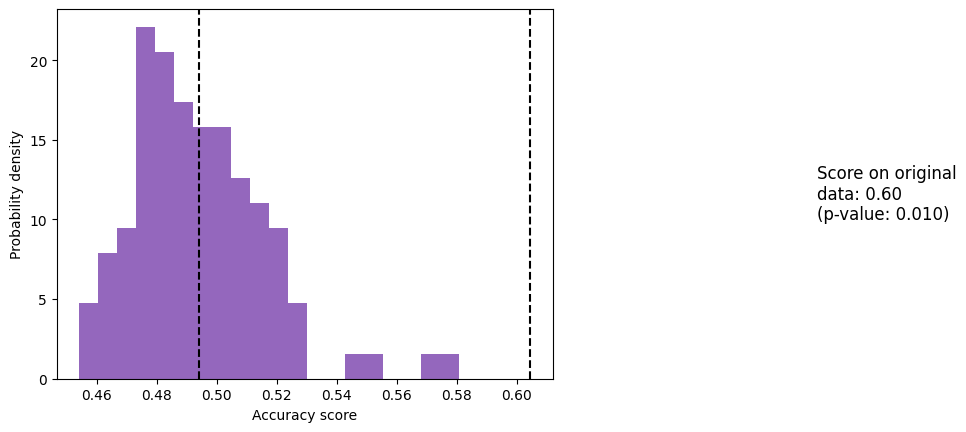

Mean Accuracy: 0.456 (0.216)


<Figure size 640x480 with 0 Axes>

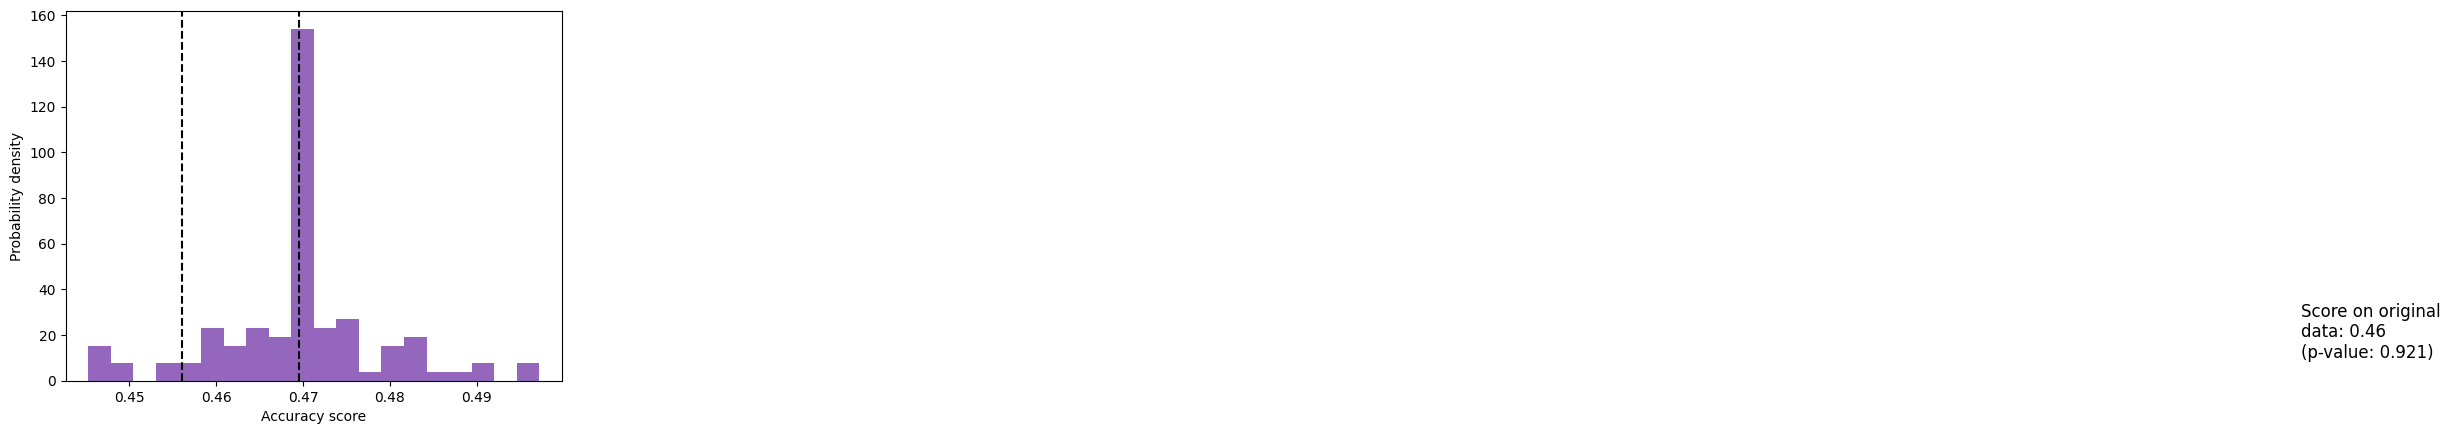

Mean Accuracy: 0.593 (0.159)


<Figure size 640x480 with 0 Axes>

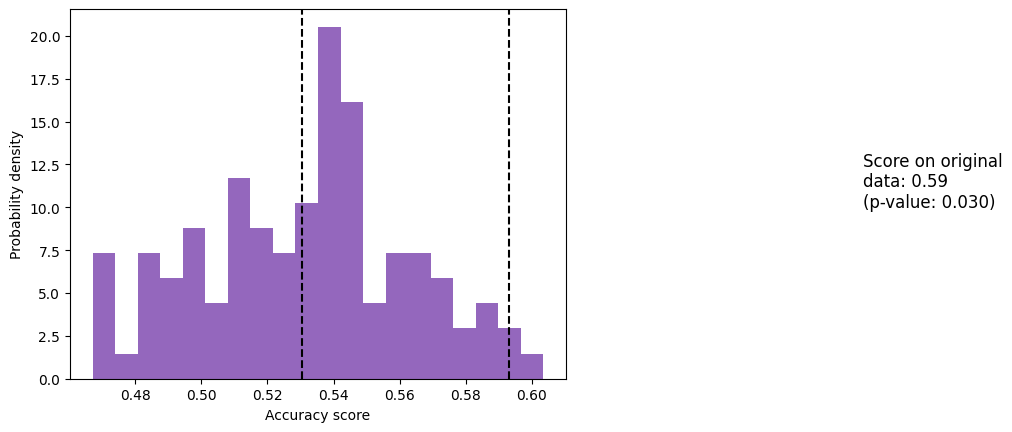

Mean Accuracy: 0.477 (0.247)


<Figure size 640x480 with 0 Axes>

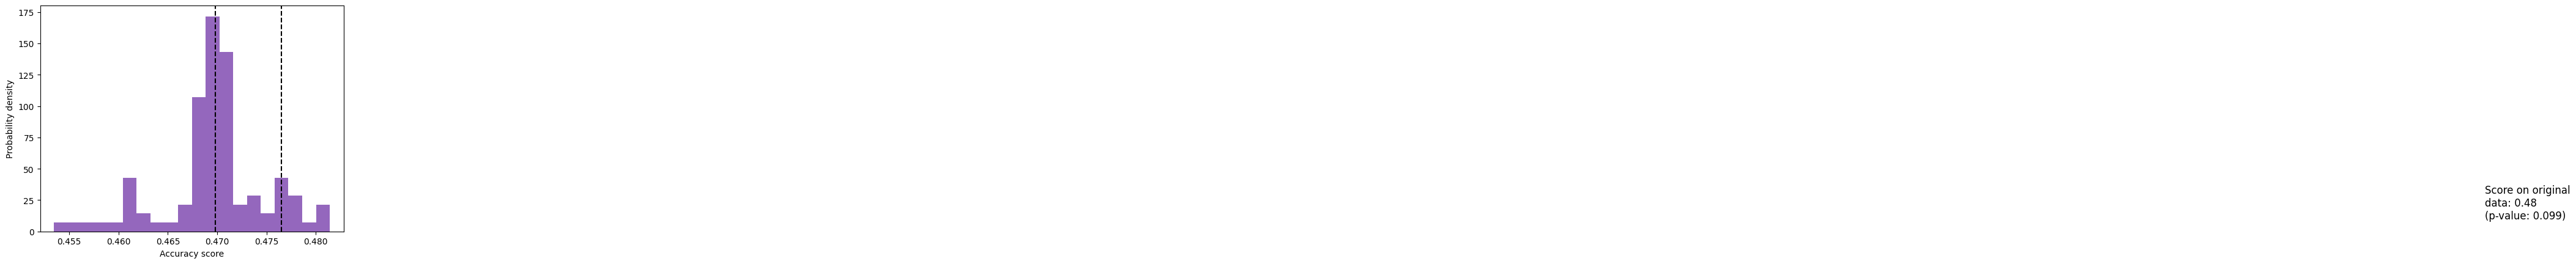

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [72]:
o=single_lda(df_for_lda)

In [73]:
o

,mean_accuracy,std,mean_score,perm_accuaracy,p-value,perm_std
speed,0.591412,0.148051,0.590238,0.555081,0.001996,0.001999
rev_run,0.635761,0.159647,0.588046,0.599721,0.001996,0.001919


In [19]:
o.to_csv(r"C:\Users\Jalaja Madhusudhanan\Desktop\autoscope_stage position\single_behavior_cv_forManuscript.csv")

In [19]:
from sklearn.impute import SimpleImputer
imp=SimpleImputer(strategy='mean')
dk=imp.fit_transform(df_for_lda.drop({'target','group'}, axis=1))
df_pls=pd.DataFrame(data=np.c_[dk,df_for_lda['group'],df_for_lda['target']])
df_pls.columns=df_for_lda.columns
df_pls

,speed,Angular_speed,rev_run,curvature,head_frequency,roam_dwell,group,target
0,0.055587,6.805210,10.25,23.661260,1.74,1.0,1.0,1.0
1,0.188738,1.844813,26.65,23.706435,2.16,1.0,1.0,1.0
2,0.140867,2.511997,59.85,23.596653,2.22,1.0,1.0,0.0
3,0.089850,1.929547,11.75,25.481219,2.00,1.0,1.0,1.0
4,0.136494,8.958600,8.85,24.112978,2.00,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...
317,0.162188,1.510567,50.25,26.841334,2.00,1.0,25.0,0.0
318,0.122387,2.139916,140.25,24.531885,1.92,1.0,25.0,1.0
319,0.172223,1.744573,62.35,24.827768,2.10,1.0,25.0,1.0
320,0.127670,2.027044,25.35,26.036395,2.10,1.0,25.0,0.0


In [22]:
x=df_pls.drop({'target','group'}, axis=1)
y=df_pls['target']

multiple_features =df_pls
best_single_feature=df_pls['speed']

pls = PLSRegression(n_components=2) # Modify the number of components accordingly ( max 10)
pls.fit(x,y)
c=pd.DataFrame(data=pls.transform(x), columns=['PLS1','PLS2'])
pls_df_for_lda = pd.DataFrame(data=np.c_[c[['PLS1', 'PLS2']], df_pls['target'], df_pls['group']], columns=['PLS1', 'PLS2', 'target', 'group'])

In [42]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import permutation_test_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression

def LDA_accuracy(data):
     results_df = pd.DataFrame(columns=['mean_accuracy', 'std_accuracy','perm_accuracy','pvalue','mean_score'])

     X_lda=data.drop({'target','group'}, axis=1)
     y_lda = data['target'].values.ravel()  # Ensure 1-D target array
     groups = data['group'].values.ravel()
            
     model= LinearDiscriminantAnalysis()
        #model= LogisticRegression()
     model.fit(X_lda,y_lda)
     cv= StratifiedGroupKFold(n_splits=10,shuffle=True,random_state=0)
     # cv = RepeatedStratifiedKFold(n_splits=10, random_state=None)
        # cv=GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        #cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        #cv=StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        # logo = LeaveOneGroupOut()
        # n_splits=logo.get_n_splits(X, y, groups)
        # cv=logo
        
     scores, perm_scores, pvalue = permutation_test_score(model, X_lda, y_lda, scoring="f1_weighted", cv=cv,groups=groups, n_permutations=1000)
     cv_scores = cross_val_score(model, X_lda, y_lda, scoring="accuracy", cv=cv,groups=groups,n_jobs=-1)
     print('Mean Accuracy: %.3f (%.3f)' % (mean(scores), std(cv_scores)))
        #print(scores)
     m=(mean(scores))
     s=(std(cv_scores))
     perm_mean_score=(mean(perm_scores))
     import matplotlib.pyplot as plt

     fig, ax = plt.subplots()

     hist_data, bins, _ = ax.hist(perm_scores, bins=20, density=True, color="tab:purple")
        # Calculate the x-coordinates for the shaded region
     ax.errorbar(m, hist_data.max(), xerr=s, color="gray", lw=2, capsize=5)

     ax.axvline(m, ls="--", color="k")
     score_label = f"Score on original\ndata: {m:.2f}\n(p-value: {pvalue:.3f})"
     ax.text(0.7, 10, score_label, fontsize=12)
     ax.set_xlabel("Accuracy score")
     _ = ax.set_ylabel("Probability density")
     plt.show()
     results_df.loc[0,'mean_accuracy'] = cv_scores.mean()
     results_df.loc[0, 'perm_accuracy'] = perm_scores.mean()
     results_df.loc[0,'mean_score'] = scores.mean()
     results_df.loc[0,'std_accuracy'] = cv_scores.std()
     results_df.loc[0,'pvalue'] = pvalue
     results_df.loc[0,'perm_std']=std(perm_scores)

     return results_df


In [43]:
x=df_prestim_imputed.drop({'target','group'}, axis=1)
y=df_prestim_imputed['target']

# best_single_feature = df_imputed[['speed','target','group']]

# multiple_features =df_imputed

pls = PLSRegression(n_components=2) # Modify the number of components accordingly ( max 10)
pls.fit(x,y)
c=pd.DataFrame(data=pls.transform(x), columns=['PLS1','PLS2'])
#c=pd.DataFrame(data=pls.transform(X), columns=['PLS1','PLS2','PLS3'])

pls_df_for_lda = pd.DataFrame(data=np.c_[c[['PLS1', 'PLS2']], df_prestim_imputed['target'], df_prestim_imputed['group']], columns=['PLS1', 'PLS2', 'target', 'group'])

def LDA_accuracy(data):
     results_df = pd.DataFrame(columns=['mean_accuracy', 'std_accuracy','perm_accuracy','pvalue','mean_score'])

     X_lda=data.drop({'target','group'}, axis=1)
     y_lda = data['target'].values.ravel()  # Ensure 1-D target array
     groups = data['group'].values.ravel()
            
     model= LinearDiscriminantAnalysis()
        #model= LogisticRegression()
     model.fit(X_lda,y_lda)
     # cv = RepeatedStratifiedKFold(n_splits=10, random_state=None)
     cv= StratifiedGroupKFold(n_splits=10,shuffle=True,random_state=0)
        #cv=GroupShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        #cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        #cv=StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
        # logo = LeaveOneGroupOut()
        # n_splits=logo.get_n_splits(X, y, groups)
        # cv=logo
        
     scores, perm_scores, pvalue = permutation_test_score(model, X_lda, y_lda, scoring="f1_weighted", cv=cv,groups=groups, n_permutations=2000, random_state=0)
     cv_scores = cross_val_score(model, X_lda, y_lda, scoring="accuracy", cv=cv,groups=groups,n_jobs=1)
     print('Mean Accuracy: %.3f (%.3f)' % (mean(scores), std(cv_scores)))
        #print(scores)
     m=(mean(scores))
     s=(std(cv_scores))
     perm_mean_score=(mean(perm_scores))
     import matplotlib.pyplot as plt

     fig, ax = plt.subplots()

     hist_data, bins, _ = ax.hist(perm_scores, bins=20, density=True, color="tab:purple")
        # Calculate the x-coordinates for the shaded region
     ax.errorbar(m, hist_data.max(), xerr=s, color="gray", lw=2, capsize=5)

     ax.axvline(m, ls="--", color="k")
     score_label = f"Score on original\ndata: {m:.2f}\n(p-value: {pvalue:.3f})"
     ax.text(0.7, 10, score_label, fontsize=12)
     ax.set_xlabel("Accuracy score")
     _ = ax.set_ylabel("Probability density")
     plt.show()
     results_df.loc[0,'mean_accuracy'] = cv_scores.mean()
     results_df.loc[0, 'perm_accuracy'] = perm_scores.mean()
     results_df.loc[0,'mean_score'] = scores.mean()
     results_df.loc[0,'std_accuracy'] = cv_scores.std()
     results_df.loc[0,'pvalue'] = pvalue
     results_df.loc[0,'perm_std']=std(perm_scores)

     return results_df


In [25]:
 LDA_accuracy(multiple_features)

NameError: name 'multiple_features' is not defined

In [44]:
 LDA_accuracy(pls_df_for_lda)

KeyboardInterrupt: 

Mean Accuracy: 0.618 (0.115)


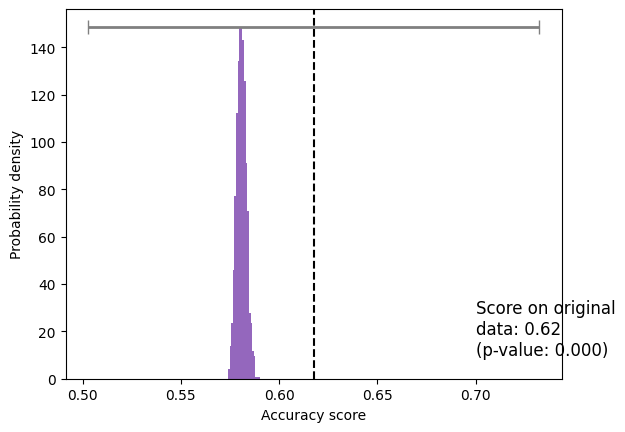

In [45]:
# best_single_feature_accuracy = LDA_accuracy(best_single_feature)
# pc_accuracy = LDA_accuracy(pc_for_lda)
# multiple_features_accuracy = LDA_accuracy(multiple_features)
# # pls_accuracy,pls_loadings = LDA_accuracy(df)
pls_accuracy = LDA_accuracy(pls_df_for_lda)
#plot  std_accuracy as shaded area

# get the column name correspond to max value of ecach row of multiple_neurons_accuracy
# pls_loadings.iloc[:, :-1].astype(float).idxmax(axis=1)

In [46]:
pls_accuracy 

,mean_accuracy,std_accuracy,perm_accuracy,pvalue,mean_score,perm_std
0,0.617602,0.114756,0.580848,0.0005,0.617602,0.002519
